# Notebook 01: Preprocessing

This notebook gets the bank marketing dataset ready for modelling. We load and inspect the data, remove a feature that causes data leakage, fill in missing values, encode categorical variables, and split the data into training and test sets.

**Dataset:** bank-full.csv from the UCI ML Repository (45,211 rows, 16 features)

In [1]:
import os
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

## Load and Inspect


In [2]:
df = pd.read_csv('../data/bank-full.csv', sep=';')
print(f'Shape: {df.shape}')
df.head()

Shape: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [4]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


## Missing Values

This dataset does not use NaN for missing values. Missing entries in categorical columns are encoded as the string 'unknown'. Not all of these are genuine missing data though, so we need to treat them differently depending on the column.

- `job` (0.6%) and `education` (4.1%) are genuinely unknown entries. We replace these with the column mode.
- `contact` (28.8%) — 'unknown' means the contact type was simply not recorded. This is its own valid category and should not be imputed.
- `poutcome` (81.7%) — 'unknown' means the client had no previous campaign contact at all. This is completely different from 'failure' and replacing it with the mode would corrupt the column. We keep it as a valid category.

In [5]:
print('Columns with unknown values:')
print('-' * 40)
for col in df.select_dtypes(include='object').columns:
    n = (df[col] == 'unknown').sum()
    if n > 0:
        print(f'  {col:20s}: {n:5d}  ({n / len(df):.1%})')

Columns with unknown values:
----------------------------------------
  job                 :   288  (0.6%)
  education           :  1857  (4.1%)
  contact             : 13020  (28.8%)
  poutcome            : 36959  (81.7%)


## Removing the Duration Feature

The dataset has a column called duration which records how long the last phone call lasted in seconds. This looks like useful information but it causes a data leakage problem.

The problem is that call duration is only known after the call has ended, and at that point the outcome is already decided. If we train a model with this feature, it learns from information that would not exist at prediction time. The UCI dataset documentation flags this directly and says it should only be used for benchmark comparisons, not realistic models.

We print the correlation first to show how misleadingly strong it is, then drop the column.

In [6]:
y_temp = (df['y'] == 'yes').astype(int)
corr_val = df['duration'].corr(y_temp)
print(f'Correlation of duration with target: {corr_val:.4f}')
print('This correlation exists only because duration is recorded after the outcome is known.')

df.drop(columns=['duration'], inplace=True)
print(f'Column dropped. Remaining columns: {df.shape[1]}')

Correlation of duration with target: 0.3945
This correlation exists only because duration is recorded after the outcome is known.
Column dropped. Remaining columns: 16


## Encode the Target

The target column y contains 'yes' or 'no' strings. We convert it to 1 and 0 for use with scikit-learn. We also check the class split here because the imbalance will affect how we train and evaluate the models.

In [7]:
df['y'] = (df['y'] == 'yes').astype(int)

print('Target distribution:')
print(df['y'].value_counts())
pos_rate = df['y'].mean()
print(f'Subscription rate: {pos_rate:.2%}')
print('The dataset is imbalanced. Around 88% of contacts did not subscribe.')

Target distribution:
y
0    39922
1     5289
Name: count, dtype: int64
Subscription rate: 11.70%
The dataset is imbalanced. Around 88% of contacts did not subscribe.


## Fill Unknown Values

We only apply mode imputation to `job` and `education`, where 'unknown' represents genuinely missing data. The `contact` and `poutcome` columns are left untouched — their 'unknown' entries are meaningful categories that the one-hot encoding will handle as their own indicator columns.

In [8]:
impute_cols = ['job', 'education']

for col in impute_cols:
    if (df[col] == 'unknown').any():
        mode_val = df.loc[df[col] != 'unknown', col].mode()[0]
        df[col] = df[col].replace('unknown', mode_val)
        print(f'  {col}: unknown replaced with mode = {mode_val!r}')

print('\ncontact and poutcome unknown values kept as valid categories.')

  job: unknown replaced with mode = 'blue-collar'
  education: unknown replaced with mode = 'secondary'

contact and poutcome unknown values kept as valid categories.


## Handling the pdays Sentinel Value

The `pdays` column records how many days passed since the client was last contacted from a previous campaign. However, -1 is used as a sentinel value meaning the client was never previously contacted — not an actual number of days. With 81.7% of rows set to -1, treating it as a plain numeric value would be misleading after scaling.

We split this into two features:
- `contacted_before` — a binary flag (1 = had a prior campaign contact, 0 = did not)
- `pdays` — the actual number of days, with -1 replaced by 0 for the rows with no prior contact

In [9]:
contacted_count = (df['pdays'] != -1).sum()
print(f'Clients with a previous campaign contact: {contacted_count:,} ({contacted_count/len(df):.1%})')

df['contacted_before'] = (df['pdays'] != -1).astype(int)
df['pdays'] = df['pdays'].replace(-1, 0)

print(f'pdays range after fix: {df["pdays"].min()} to {df["pdays"].max()}')
print(f'contacted_before:\n{df["contacted_before"].value_counts()}')

Clients with a previous campaign contact: 8,257 (18.3%)
pdays range after fix: 0 to 871
contacted_before:
contacted_before
0    36954
1     8257
Name: count, dtype: int64


## One-Hot Encoding

Scikit-learn models cannot work with string labels directly, so we convert all categorical columns into binary columns using one-hot encoding. Setting drop_first=True removes the first category from each column to avoid the dummy variable trap, where one column can be perfectly predicted from the others.

In [10]:
df_encoded = pd.get_dummies(df, drop_first=True)
feature_names = [c for c in df_encoded.columns if c != 'y']

print(f'Shape after encoding: {df_encoded.shape}')
print(f'Number of features:   {len(feature_names)}')

Shape after encoding: (45211, 41)
Number of features:   40


## Train and Test Split

We split the data 80/20 using a stratified split. Stratified means the proportion of positive cases (around 12%) is kept the same in both the training set and the test set, so neither set ends up with a skewed class balance by chance.

We do not apply any feature scaling here. Scaling is handled inside each model pipeline in notebook 02, which means the scaler is fitted only on training data and never sees the test set until evaluation.

In [11]:
X = df_encoded[feature_names]
y = df_encoded['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f'Train: {X_train.shape[0]:,} samples  |  positive rate: {y_train.mean():.2%}')
print(f'Test:  {X_test.shape[0]:,} samples  |  positive rate: {y_test.mean():.2%}')

Train: 36,168 samples  |  positive rate: 11.70%
Test:  9,043 samples  |  positive rate: 11.70%


## Save the Splits

We save the preprocessed splits to CSV files so the other notebooks can load them directly without repeating the preprocessing steps.

In [12]:
os.makedirs('../data', exist_ok=True)

X_train.to_csv('../data/X_train.csv', index=False)
X_test.to_csv('../data/X_test.csv', index=False)
y_train.to_csv('../data/y_train.csv', index=False)
y_test.to_csv('../data/y_test.csv', index=False)
pd.Series(feature_names, name='feature').to_csv('../data/feature_names.csv', index=False)

print('Files saved to ../data/:')
for fname in ['X_train.csv', 'X_test.csv', 'y_train.csv', 'y_test.csv', 'feature_names.csv']:
    fpath = f'../data/{fname}'
    size_kb = os.path.getsize(fpath) / 1024
    print(f'  {fname:25s}  {size_kb:.0f} KB')

Files saved to ../data/:
  X_train.csv                7476 KB
  X_test.csv                 1870 KB
  y_train.csv                106 KB
  y_test.csv                 26 KB
  feature_names.csv          1 KB


---
## EDA

The preprocessing above cleaned and split the data. For EDA we reload the **raw CSV** with the
original string labels, this makes every chart axis readable and avoids confusion between
encoded integer columns and their real category names.


We exclude `duration` from every chart it was dropped as a leakage feature in Step 3 above.

### Load raw data

The UCI Bank Marketing CSV uses **semicolons** as separators, not commas.
Forgetting `sep=';'` produces a single-column dataframe with no errors — an easy mistake
that is hard to notice until charts look wrong.

In [13]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
os.makedirs('../figures', exist_ok=True)

# Reload the raw CSV — string labels, no encoding, so charts are human-readable.
raw = pd.read_csv('../data/bank-full.csv', sep=';')

# Drop duration immediately. It was removed in Step 3 as a leakage feature
# and must not appear in any EDA chart either.
raw = raw.drop(columns=['duration'])

# Add a numeric version of the target for correlation calculations later.
raw['subscribed'] = (raw['y'] == 'yes').astype(int)

print(f'Rows: {len(raw):,}  |  Columns: {raw.shape[1]}')
raw.head()

Rows: 45,211  |  Columns: 17


,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,pdays,previous,poutcome,y,subscribed
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,1,-1,0,unknown,no,0
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,1,-1,0,unknown,no,0
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,1,-1,0,unknown,no,0
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,1,-1,0,unknown,no,0
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,1,-1,0,unknown,no,0


### Class distribution

The target column `y` records whether the client subscribed to a term deposit.
We plot a bar chart and a pie chart together so the imbalance is immediately obvious.

**Why this matters for modelling:**  
Roughly 88 % of contacts did not subscribe. A model that predicts 'no' for every single row
achieves ~88 % accuracy while being completely useless for the bank. This means **accuracy
alone is a misleading metric** here — we must use ROC-AUC, Precision-Recall AUC, and F1
to judge the models fairly in the modelling notebook.

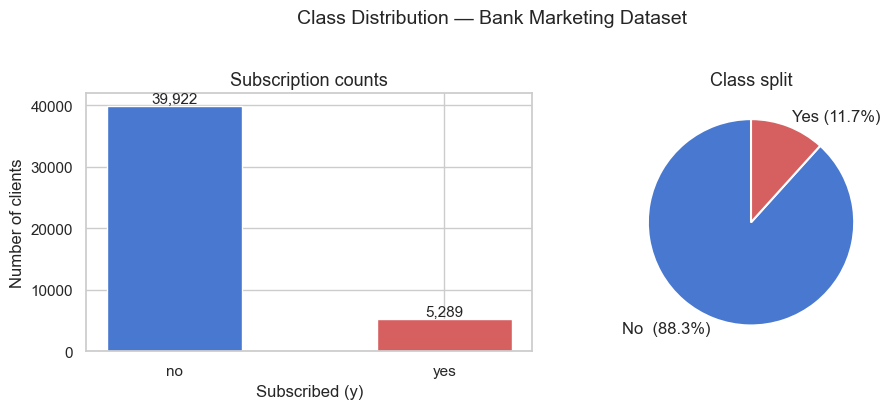

Imbalance ratio  no : yes  =  7.5 : 1


In [14]:
counts = raw['y'].value_counts()                      # no: 39922, yes: 5289
pct    = raw['y'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# ── Bar chart ──────────────────────────────────────────────────
colours = ['#4878CF', '#D65F5F']   # blue = no, red = yes
axes[0].bar(counts.index, counts.values, color=colours,
            edgecolor='white', width=0.5)
axes[0].set_title('Subscription counts', fontsize=13)
axes[0].set_xlabel('Subscribed (y)')
axes[0].set_ylabel('Number of clients')
for i, (label, val) in enumerate(counts.items()):
    axes[0].text(i, val + 500, f'{val:,}', ha='center', fontsize=11)

# ── Pie chart ──────────────────────────────────────────────────
pie_labels = [f'No  ({pct["no"]:.1f}%)', f'Yes ({pct["yes"]:.1f}%)']
axes[1].pie(
    counts.values,
    labels=pie_labels,
    colors=colours,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
    textprops={'fontsize': 12},
)
axes[1].set_title('Class split', fontsize=13)

fig.suptitle('Class Distribution — Bank Marketing Dataset', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../figures/01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Imbalance ratio  no : yes  =  {counts["no"]/counts["yes"]:.1f} : 1')

### Numeric feature distributions by class

Overlapping normalised histograms (`density=True`) for each numeric column, coloured by
outcome. Using **density** (rather than raw counts) puts both groups on the same vertical
scale — essential here because there are ~7.5× more 'no' rows than 'yes' rows.
Without normalisation, the 'yes' bars would be nearly invisible.

**Note on `pdays`:** In the raw data -1 is a sentinel value meaning
'never contacted before a previous campaign' — not a real day count.
Your partner's preprocessing replaced -1 with 0 and added a binary `contacted_before` flag.
In the raw histogram below you will see a massive spike at -1 for `pdays`;
the modelling notebook will use the cleaned version where that sentinel has been handled.

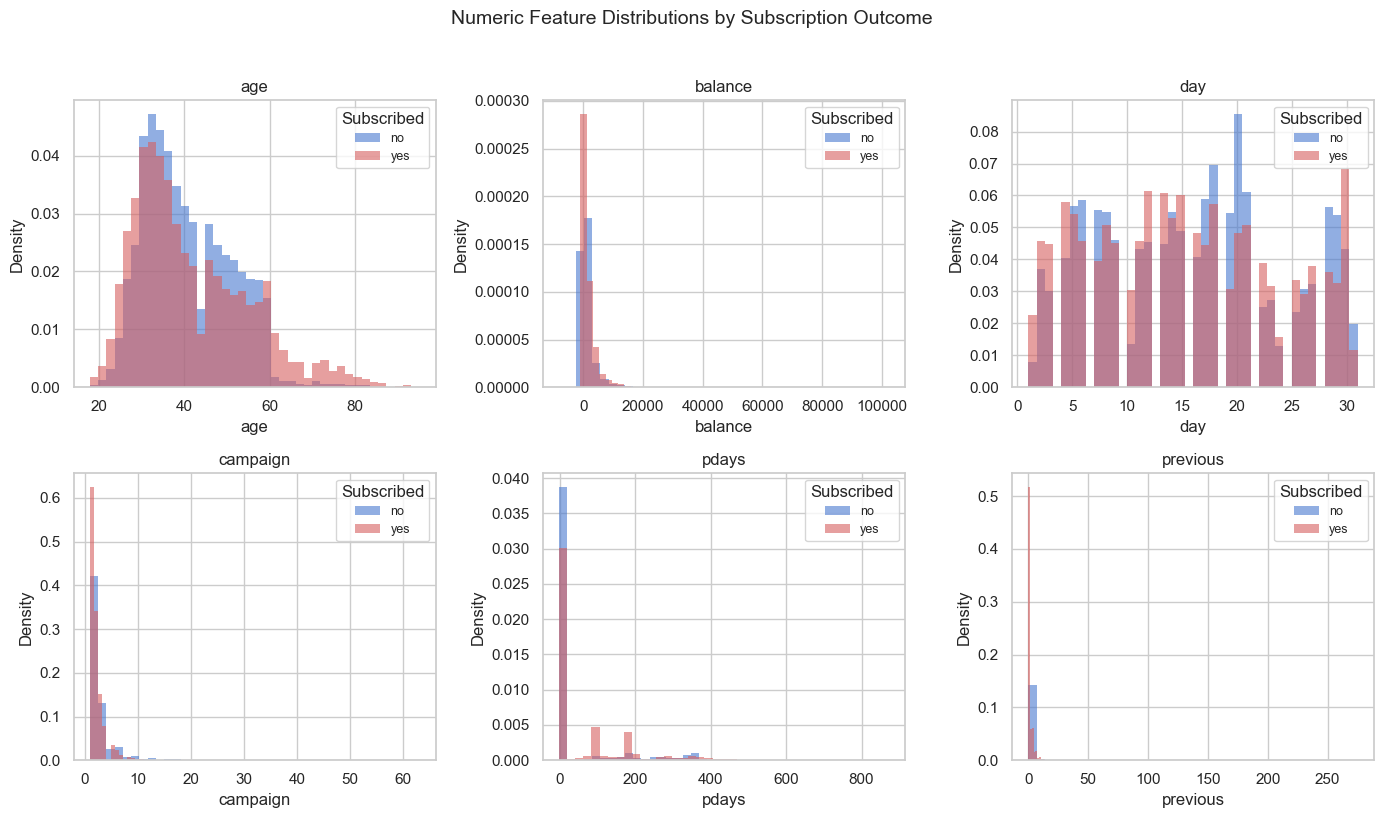

In [15]:
# Numeric columns to plot (duration excluded — leakage feature)
num_cols = ['age', 'balance', 'day', 'campaign', 'pdays', 'previous']

palette = {'no': '#4878CF', 'yes': '#D65F5F'}

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    for label, colour in palette.items():
        subset = raw.loc[raw['y'] == label, col]
        ax.hist(
            subset,
            bins=40,
            density=True,      # normalise so both classes are comparable
            alpha=0.6,
            color=colour,
            label=label,
            edgecolor='none',
        )
    ax.set_title(col, fontsize=12)
    ax.set_xlabel(col)
    ax.set_ylabel('Density')
    ax.legend(title='Subscribed', fontsize=9)

fig.suptitle('Numeric Feature Distributions by Subscription Outcome',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../figures/02_numeric_histograms.png', dpi=150, bbox_inches='tight')
plt.show()

### Correlation heatmap

Pearson correlations between all numeric features and a binary version of the target
(1 = subscribed, 0 = not). We mask the upper triangle to avoid printing each value twice.
The colour scale diverges around zero — red indicates positive correlation with subscribing,
blue indicates negative.

`previous` (number of contacts in previous campaigns) and `pdays` both show positive
correlations with the target — clients who were contacted before and didn't have to wait
long after the last contact are more likely to subscribe.

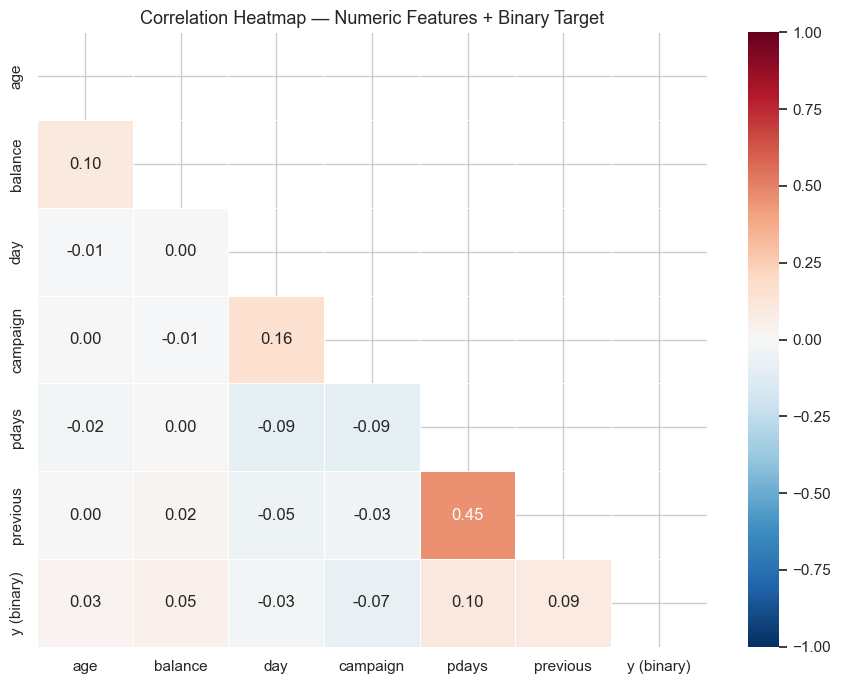

In [16]:
corr_df = raw[num_cols].copy()
corr_df['y (binary)'] = raw['subscribed']   # include target as numeric column

corr_matrix = corr_df.corr()

# Mask the upper triangle — it mirrors the lower triangle exactly,
# so showing it would just add clutter without any new information.
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    ax=ax,
)
ax.set_title('Correlation Heatmap — Numeric Features + Binary Target', fontsize=13)
plt.tight_layout()
plt.savefig('../figures/03_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### Subscription rate by category

For each categorical feature we compute the percentage of clients in each category who
subscribed. Bars are sorted highest to lowest so the most discriminative categories stand out.

Standout patterns:
- **`month`** — March, December, October, September all convert above 43 %,
  while May (the most-contacted month) sits at only 6.7 %.
  Campaign timing seems to matter more than individual client traits.
- **`poutcome`** — Clients whose *previous* campaign ended in success convert at 64.7 %.
  Clients with no prior contact convert at only 9.2 %.
- **`contact`** — The 'unknown' contact type converts at just 4.1 %,
  well below cellular (14.9 %) and telephone (13.4 %).

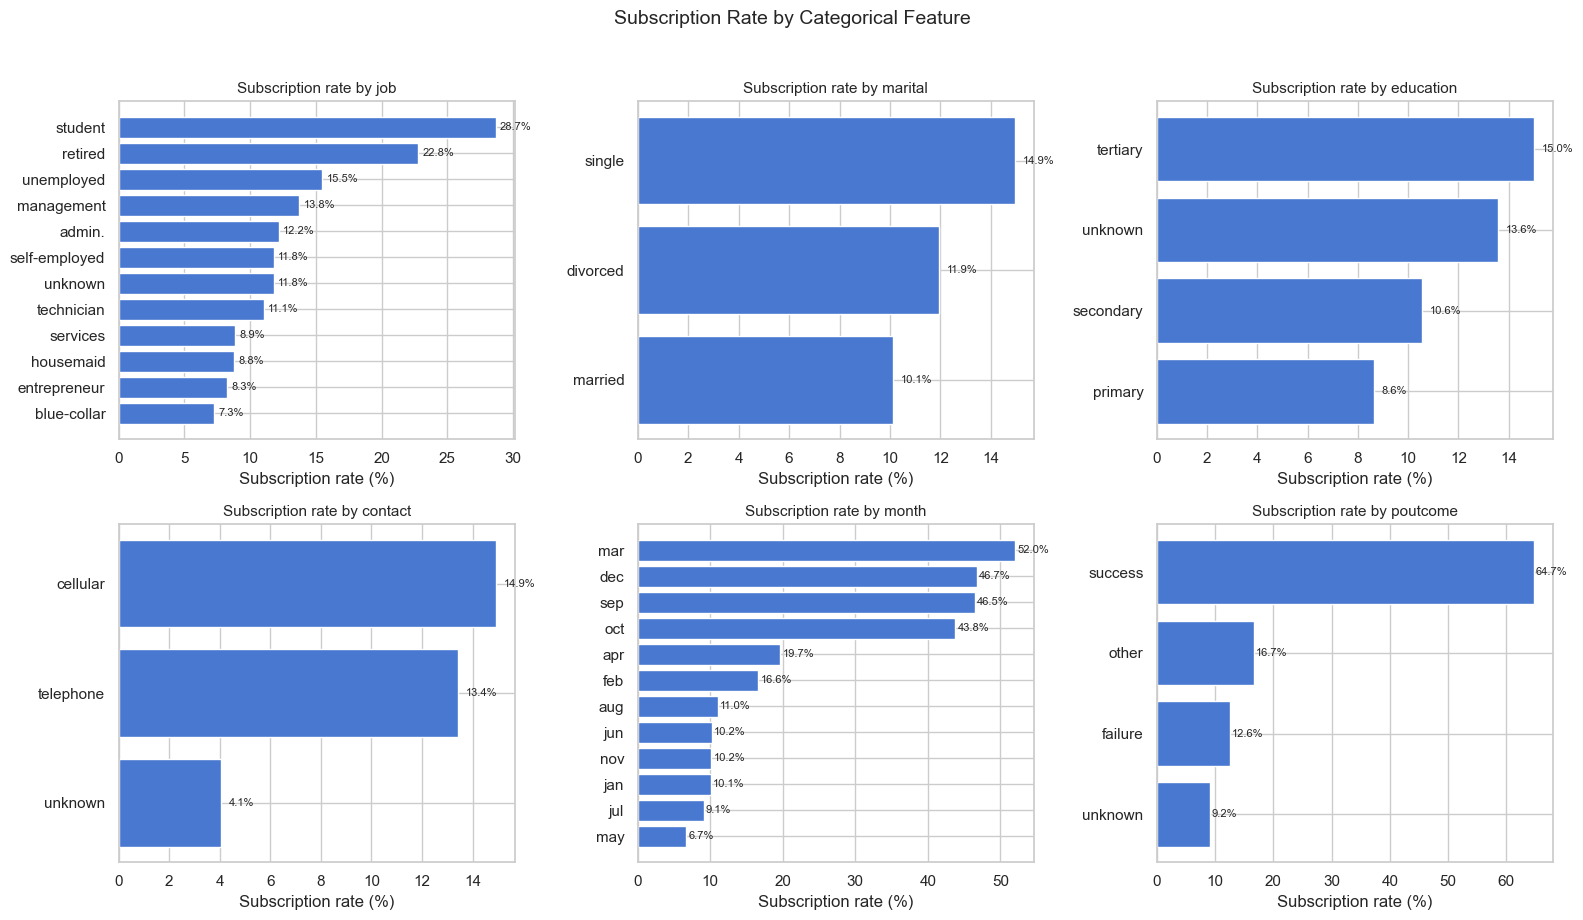

In [17]:
cat_cols = ['job', 'marital', 'education', 'contact', 'month', 'poutcome']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, col in zip(axes, cat_cols):
    # Compute subscription rate per category, sort descending so best category is at top
    rates = (
        raw.groupby(col)['subscribed']
        .mean()
        .sort_values(ascending=False)
        .reset_index()
    )
    rates.columns = [col, 'rate']

    bars = ax.barh(rates[col], rates['rate'] * 100,
                   color='#4878CF', edgecolor='white')
    ax.set_xlabel('Subscription rate (%)')
    ax.set_title(f'Subscription rate by {col}', fontsize=11)
    ax.invert_yaxis()   # highest rate at top of chart

    # Annotate each bar with the exact percentage value
    for bar, val in zip(bars, rates['rate']):
        ax.text(val * 100 + 0.3,
                bar.get_y() + bar.get_height() / 2,
                f'{val*100:.1f}%', va='center', fontsize=8)

fig.suptitle('Subscription Rate by Categorical Feature', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../figures/04_categorical_rates.png', dpi=150, bbox_inches='tight')
plt.show()

### Box plots of numeric features grouped by outcome

Box plots show the median, IQR (box), and outliers for each numeric feature,
split by subscription outcome. They complement the histograms by highlighting
median differences between the two groups more clearly.

We clip each column at its 99th percentile before plotting — `balance` reaches 102,127
and without clipping the whiskers would compress the main box into a thin line.
This is for display only; the clipping is not applied to the data used in modelling.

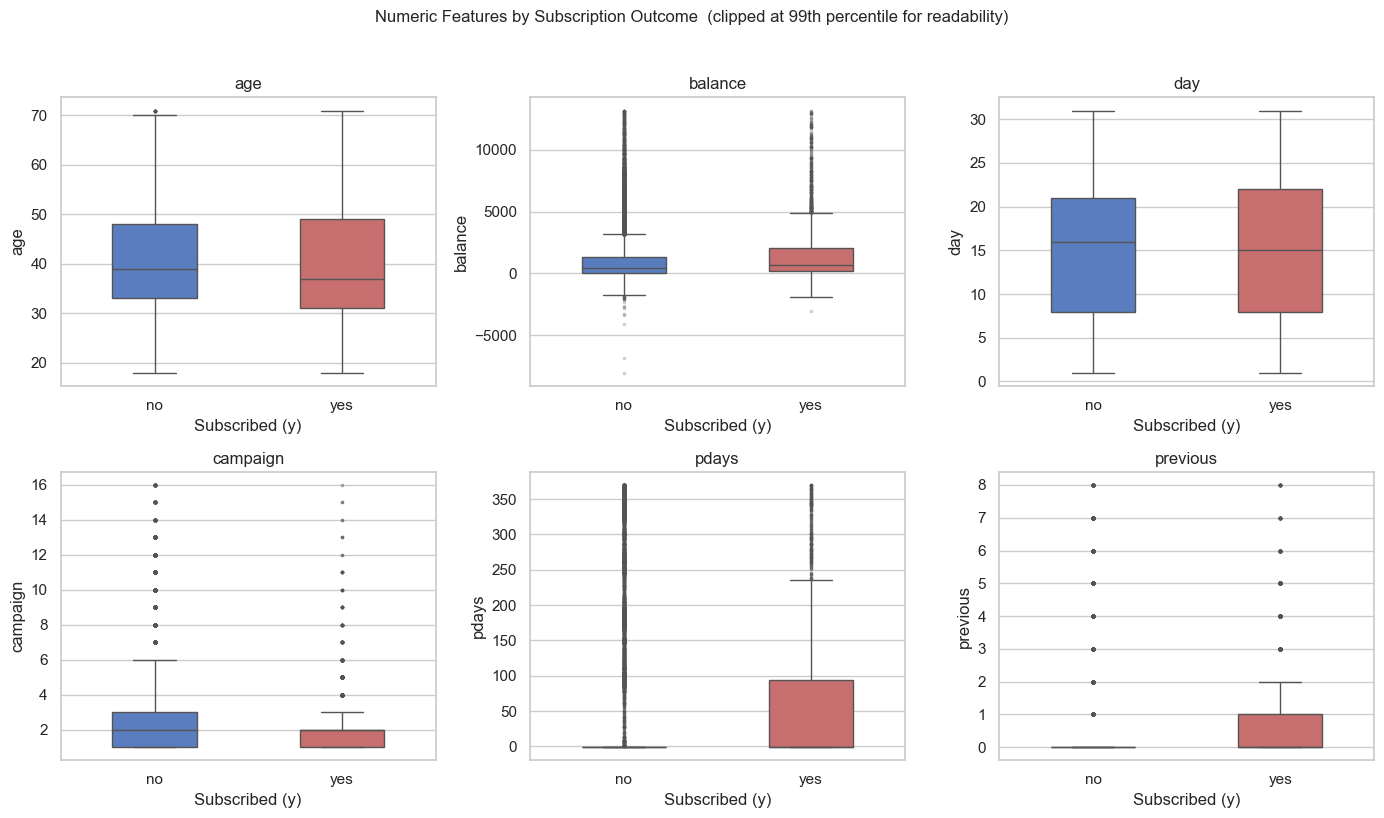

In [18]:
palette = {'no': '#4878CF', 'yes': '#D65F5F'}

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    # Clip at the 99th percentile so extreme outliers do not squash the main box.
    # This is purely a display choice — the underlying data is unchanged.
    p99 = raw[col].quantile(0.99)
    plot_data = raw[raw[col] <= p99]

    sns.boxplot(
        data=plot_data,
        x='y',
        y=col,
        palette=palette,
        width=0.45,
        order=['no', 'yes'],
        flierprops={'marker': '.', 'alpha': 0.3, 'markersize': 3},
        ax=ax,
    )
    ax.set_title(col, fontsize=12)
    ax.set_xlabel('Subscribed (y)')

fig.suptitle(
    'Numeric Features by Subscription Outcome  (clipped at 99th percentile for readability)',
    fontsize=12, y=1.02
)
plt.tight_layout()
plt.savefig('../figures/05_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

### Key Observations

- **Class imbalance is severe (88 % vs 12 %).** A model that blindly predicts 'no'
  for every client achieves 88 % accuracy but has zero practical value to the bank.
  We must evaluate models on ROC-AUC and Precision-Recall curves, not accuracy alone.
  All three classifiers in Notebook 02 will use `class_weight='balanced'` or equivalent
  to account for this.

- **Previous campaign outcome (`poutcome`) is the strongest categorical signal.**
  Clients whose last campaign ended in *success* subscribe at 64.7 %, compared to
  just 9.2 % for those with no prior contact. After one-hot encoding, this feature
  should appear near the top of the Random Forest and GBT feature importance charts.

- **Campaign timing matters more than most client traits.**
  March, October, September, and December show subscription rates above 43 %,
  while May — the single most-contacted month — sits at only 6.7 %.
  This is a strong argument for the bank to focus future campaigns on Q4.

- **Over-contacting within a campaign is counter-productive.**
  The `campaign` box plots and histograms both show that clients called more than 3–4
  times in this campaign were *less* likely to subscribe.
  The bank should consider setting a maximum contact limit per campaign.

- **`pdays` and `previous` carry real signal but need careful interpretation.**
  81.7 % of clients have `pdays = -1` (never previously contacted).
  Your partner's preprocessing handled this correctly: replace -1 with 0 and add a
  binary `contacted_before` flag. In the raw histogram the -1 sentinel dominates,
  masking the actual signal. The modelling notebook uses the cleaned version.